In [117]:
import os
import sys

import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath(os.path.join("modelling", '../..')))

from utility import plot

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM

from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [118]:
SEED = 42
PLOT_DPI = 100

# TRAIN_DATA_FILE = "../data/preprocessed_skab_dataset_fe_train.csv"
# TRAIN_DATA_FILE = "../data/preprocessed_skab_dataset_train_undersampled_smote_fe.csv"
TRAIN_DATA_FILE = "../data/preprocessed_skab_dataset_train_undersampled_adasyn_fe.csv"

TEST_DATA_FILE = "../data/preprocessed_skab_dataset_fe_test.csv"

USE_LDA = False
USE_FE = True

In [119]:
dataframe_train = pd.read_csv(TRAIN_DATA_FILE)
# dataframe_train.set_index(pd.to_datetime(dataframe_train.datetime), drop=True, inplace=True)
# dataframe_train.drop(columns=["datetime"], inplace=True)

if not USE_FE:
    og_columns = ["Accelerometer1RMS", "Accelerometer2RMS", "Current", "Pressure", "Temperature", "Thermocouple", "Voltage", "Volume Flow RateRMS", "anomaly", "description"]
    dataframe_train = dataframe_train.drop(columns=[col for col in dataframe_train.columns if col not in og_columns])

dataframe_train.head()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Temperature_Difference,Hydraulic_Power,Electrical_Power,Actual_Efficiency,Vibration_Intensity_Ratio,AccelerometerRMS_pu_Pressure,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,anomaly,description
0,0.219595,0.267058,2.97205,1.074847,88.9166,28.9319,227.339,127.0000,76.492320,0.008463,...,59.9847,227.509732,574.313444,0.396142,0.822275,0.000462,0.154822,0.006604,0.0,No Anomaly
1,0.028225,0.042124,1.43210,1.401284,68.6462,24.7640,245.677,32.9805,171.550171,0.042488,...,43.8822,77.025248,299.058927,0.257559,0.670037,0.000036,0.229541,0.005869,0.0,No Anomaly
2,0.214053,0.259569,2.22898,1.730701,88.2787,29.6790,227.822,127.0000,102.209082,0.013628,...,58.5997,366.332439,431.639079,0.848701,0.824648,0.000437,0.204520,0.014483,0.0,No Anomaly
3,0.255422,0.294430,2.99871,1.074847,86.2073,28.8126,232.379,126.0000,77.492989,0.008531,...,57.3947,225.718316,592.311646,0.381080,0.867514,0.000597,0.145544,0.006640,0.0,No Anomaly
4,0.081667,0.129274,1.56118,0.733489,87.2407,22.1358,234.136,77.0000,149.973738,0.009526,...,65.1049,94.131282,310.699174,0.302966,0.631739,0.000137,0.280788,0.004654,0.0,No Anomaly


In [120]:
dataframe_test = pd.read_csv(TEST_DATA_FILE)
# dataframe_test.set_index(pd.to_datetime(dataframe_test.datetime), drop=True, inplace=True)
# dataframe_test.drop(columns=["datetime"], inplace=True)

if not USE_FE:
    og_columns = ["Accelerometer1RMS", "Accelerometer2RMS", "Current", "Pressure", "Temperature", "Thermocouple", "Voltage", "Volume Flow RateRMS", "anomaly", "description"]
    dataframe_test = dataframe_test.drop(columns=[col for col in dataframe_test.columns if col not in og_columns])

dataframe_test.head()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Temperature_Difference,Hydraulic_Power,Electrical_Power,Actual_Efficiency,Vibration_Intensity_Ratio,AccelerometerRMS_pu_Pressure,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,description,anomaly
0,0.210323,0.262893,2.65864,1.074847,88.6217,29.3147,230.091,126.677,86.544624,0.008485,...,59.3070,226.931105,519.969766,0.436431,0.800033,0.000436,0.170436,0.007359,No Anomaly,0.0
1,0.028297,0.042536,0.81412,0.745430,68.0318,24.2354,232.174,32.000,285.184002,0.023295,...,43.7964,39.756362,160.664872,0.247449,0.665238,0.000038,0.423439,0.005650,No Anomaly,0.0
2,0.028185,0.041387,0.81061,1.073357,68.8750,24.7075,208.422,32.000,257.117479,0.033542,...,44.1675,57.245837,143.606614,0.398630,0.681015,0.000036,0.479609,0.009025,No Anomaly,0.0
3,0.027955,0.042217,1.12593,1.073357,68.9973,24.7679,235.556,27.000,209.210164,0.039754,...,44.2294,48.301175,225.436632,0.214256,0.662168,0.000044,0.306061,0.004844,Inlet Valve Malfunction,12.0
4,0.211749,0.272061,2.65451,1.402774,90.2739,27.8473,225.678,123.668,85.016820,0.011343,...,62.4266,289.130998,509.204832,0.567809,0.778314,0.000466,0.177284,0.009096,No Anomaly,0.0


In [121]:
scaler = StandardScaler()

values = scaler.fit_transform(dataframe_train.drop(columns=["anomaly", "description"]).values)

if USE_LDA:
    lda = LinearDiscriminantAnalysis()
    values = lda.fit_transform(values, dataframe_train.anomaly.to_numpy().ravel())
    dataframe_train_scaled = pd.DataFrame(values, columns=[f"Linear_Discriminant_{idx}" for idx in range(1, values.shape[1]+1)])
else:
    dataframe_train_scaled = pd.DataFrame(values, columns=dataframe_train.drop(columns=["anomaly", "description"]).columns)

dataframe_train_scaled = dataframe_train_scaled.assign(anomaly=dataframe_train.anomaly.values, description=dataframe_train.description.values)
dataframe_train_scaled

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Temperature_Difference,Hydraulic_Power,Electrical_Power,Actual_Efficiency,Vibration_Intensity_Ratio,AccelerometerRMS_pu_Pressure,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,anomaly,description
0,-0.309762,-0.291345,1.233701,-0.167340,0.722648,0.189079,-0.169745,0.655523,-0.747036,-0.274752,...,0.763995,0.445197,1.153168,-0.343077,0.198383,-0.389721,-0.757459,-0.510741,0.0,No Anomaly
1,-1.255479,-1.307951,-1.014486,1.312214,-2.247663,-1.285601,1.748539,-1.742152,0.644291,1.142802,...,-2.033746,-1.316263,-0.838665,-1.068324,-1.479479,-0.613934,-0.040534,-0.734470,0.0,No Anomaly
2,-0.337150,-0.325193,0.148886,2.805271,0.629174,0.453416,-0.119220,0.655523,-0.370629,-0.059599,...,0.523357,2.070153,0.120729,2.025293,0.224539,-0.402506,-0.280612,1.888438,0.0,No Anomaly
3,-0.132712,-0.167635,1.272622,-0.167340,0.325643,0.146868,0.357474,0.630021,-0.732390,-0.271953,...,0.313993,0.424228,1.283409,-0.421900,0.696976,-0.318574,-0.846488,-0.499904,0.0,No Anomaly
4,-0.991375,-0.914072,-0.826041,-1.714520,0.477071,-2.215507,0.541269,-0.619572,0.328485,-0.230487,...,1.653608,-1.116033,-0.754432,-0.830695,-1.901575,-0.560709,0.451189,-1.104691,0.0,No Anomaly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
315067,-1.258054,-1.320520,-1.142716,-0.174091,-2.294520,-1.493950,1.195587,-1.817072,0.750799,0.861144,...,-1.986993,-1.588773,-1.015100,-1.392239,-1.103480,-0.613813,0.143798,-1.172243,13.0,Outlet Valve Malfunction
315068,-1.257368,-1.320690,-1.216198,-1.829739,-2.270860,-1.479324,1.223781,-1.818230,0.855664,0.356059,...,-1.966123,-1.803495,-1.087378,-1.716289,-1.057164,-0.613707,0.239718,-1.601803,13.0,Outlet Valve Malfunction
315069,-1.257725,-1.321410,-1.145087,-0.555264,-2.283752,-1.490322,1.203285,-1.817338,0.754767,0.744995,...,-1.976008,-1.638264,-1.016894,-1.471944,-1.045736,-0.613856,0.148523,-1.279064,13.0,Outlet Valve Malfunction
315070,-1.256298,-1.320799,-1.020812,-2.024123,-2.320101,-1.494162,1.212715,-1.817076,0.599401,0.295102,...,-2.017222,-1.828006,-0.890197,-1.819154,-0.991633,-0.613598,-0.003057,-1.731752,13.0,Outlet Valve Malfunction


In [122]:
values = scaler.transform(dataframe_test.drop(columns=["anomaly", "description"]).values)

if USE_LDA:
    values = lda.transform(values)
    dataframe_test_scaled = pd.DataFrame(values, columns=[f"Linear_Discriminant_{idx}" for idx in range(1, values.shape[1]+1)])
else:
    dataframe_test_scaled = pd.DataFrame(values, columns=dataframe_test.drop(columns=["anomaly", "description"]).columns)

dataframe_test_scaled = dataframe_test_scaled.assign(anomaly=dataframe_test.anomaly.values, description=dataframe_test.description.values)
dataframe_test_scaled

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Temperature_Difference,Hydraulic_Power,Electrical_Power,Actual_Efficiency,Vibration_Intensity_Ratio,AccelerometerRMS_pu_Pressure,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,anomaly,description
0,-0.355583,-0.310169,0.776151,-0.167340,0.679435,0.324520,0.118133,0.647285,-0.599904,-0.273853,...,0.646247,0.438424,0.759919,-0.132232,-0.046752,-0.403037,-0.607644,-0.280902,0.0,No Anomaly
1,-1.255124,-1.306090,-1.916681,-1.660397,-2.337693,-1.472630,0.336030,-1.767156,2.307508,0.343155,...,-2.048654,-1.752505,-1.840130,-1.121231,-1.532368,-0.613111,1.819930,-0.801259,0.0,No Anomaly
2,-1.255676,-1.311286,-1.921805,-0.174091,-2.214135,-1.305592,-2.148598,-1.767156,1.896708,0.770098,...,-1.984177,-1.547786,-1.963569,-0.330060,-1.358484,-0.613722,2.358880,0.226571,0.0,No Anomaly
3,-1.256814,-1.307533,-1.461466,-0.174091,-2.196214,-1.284222,0.689811,-1.894666,1.195507,1.028885,...,-1.973422,-1.652486,-1.371420,-1.294939,-1.566199,-0.609900,0.693679,-1.046623,12.0,Inlet Valve Malfunction
4,-0.348536,-0.268734,0.770121,1.318966,0.921539,-0.194673,-0.343498,0.570550,-0.622266,-0.154777,...,1.188265,1.166490,0.682020,0.555304,-0.286116,-0.387580,-0.541939,0.247953,0.0,No Anomaly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7376,-1.260942,-1.318490,-1.432195,-0.174091,-2.105627,-1.209460,0.142507,-1.792658,1.075108,0.815177,...,-1.902725,-1.568726,-1.379249,-1.122618,-1.352981,-0.614587,0.734279,-0.835439,12.0,Inlet Valve Malfunction
7377,-0.360955,-0.317157,0.591852,-0.167340,0.732378,0.274844,-0.633887,0.630021,-0.578309,-0.271953,...,0.733416,0.424228,0.469277,0.045730,-0.040433,-0.404349,-0.463525,-0.126565,0.0,No Anomaly
7378,-1.259080,-1.318890,-2.201564,-0.174091,-2.296795,-1.379894,0.004844,-1.766348,3.548566,0.768715,...,-2.045700,-1.547122,-2.130855,0.072660,-1.231616,-0.614971,3.196893,0.783611,0.0,No Anomaly
7379,-0.193709,-0.199544,0.282804,1.318966,0.229340,0.385094,2.215296,0.665315,-0.289008,-0.168563,...,0.082825,1.268183,0.567833,0.742477,0.458487,-0.344110,-0.579397,0.756521,0.0,No Anomaly


In [123]:
combined = zip(dataframe_train.anomaly.values, dataframe_train.description.values)
sorted_pairs = sorted(combined, key=lambda pair: pair[0])

anomaly_ids = dict()
for i in sorted_pairs:
    # if i[0] == 0: continue
    anomaly_ids[i[0]] = i[1]

anomaly_names = [val for key, val in anomaly_ids.items()]
# anomaly_ids

In [124]:
def format_cf(cf):
    tp = cf[0, 0]
    fp = np.sum(cf[1:, 0])
    fn = np.sum(cf[0, 1:])
    tn = np.sum(cf[1:, 1:])
    return np.array([[tp, fn], [fp, tn]])

### K-Means

In [125]:
dataframe_data = dataframe_train_scaled.drop(columns=["description"])

kmeans_custom = KMeans(n_clusters=len(dataframe_data.anomaly.unique()), random_state=SEED) # n_init=1 when pre-defined
dataframe_X = dataframe_data.drop(columns=["anomaly"])
kmeans_custom.fit(dataframe_X.values)

KMeans(n_clusters=14, random_state=42)

In [126]:
unique_values, counts = np.unique(kmeans_custom.labels_, return_counts=True)

for value, count in zip(unique_values, counts):
    print(f"{value} occurs {count} times")

0 occurs 38809 times
1 occurs 20662 times
2 occurs 24058 times
3 occurs 43541 times
4 occurs 21164 times
5 occurs 36 times
6 occurs 33 times
7 occurs 10272 times
8 occurs 18999 times
9 occurs 12937 times
10 occurs 53362 times
11 occurs 8540 times
12 occurs 42127 times
13 occurs 20532 times


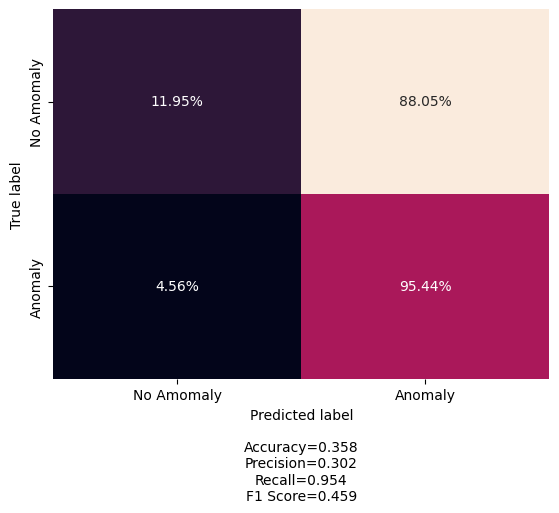

In [127]:
dataframe_data = dataframe_test_scaled.drop(columns=["anomaly", "description"])

plot.make_confusion_matrix(
    format_cf(confusion_matrix(dataframe_test_scaled.anomaly.values, kmeans_custom.predict(dataframe_data.values))),
    categories=["No Amomaly", "Anomaly",],
    count=False,
    cbar=False,
)

In [128]:
# plot.make_confusion_matrix(
#     confusion_matrix(dataframe_train_scaled.anomaly.values, kmeans_custom.labels_),
#     categories=anomaly_names,
#     count=False,
#     cbar=False,
#     figsize=(20, 20)
# )

### Isolation Forest

In [129]:
dataframe_X_train = dataframe_train_scaled.drop(columns=["anomaly", "description"])
dataframe_y_train = dataframe_train_scaled[["anomaly"]]
dataframe_X_test = dataframe_test_scaled.drop(columns=["anomaly", "description"])
dataframe_y_test = dataframe_test_scaled[["anomaly"]]

In [130]:
# dataframe_X = dataframe.drop(columns=["anomaly", "description"])
# dataframe_y = dataframe[["anomaly"]]

# X_train, X_test, y_train, y_test = train_test_split(
#                                                         dataframe_X.values, 
#                                                         dataframe_y.values.ravel(), 
#                                                         test_size=0.3, 
#                                                         random_state=SEED, 
#                                                         stratify=dataframe_y.values.ravel()
# )
# dataframe_X_train = pd.DataFrame(X_train, columns=dataframe_X.columns)
# dataframe_X_test = pd.DataFrame(X_test, columns=dataframe_X.columns)
# dataframe_y_train = pd.DataFrame(y_train, columns=dataframe_y.columns)
# dataframe_y_test = pd.DataFrame(y_test, columns=dataframe_y.columns)

In [131]:
def train_evaluate_isolation_forest(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    contamination: float = 0.01, # Proportion of outliers in the data set
    random_state: int = 42
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Trains and evaluates an Isolation Forest model for anomaly detection.
    """
    print(f"  Training Isolation Forest with contamination={contamination}...")
    model = IsolationForest(contamination=contamination, random_state=random_state, n_jobs=-1)
    model.fit(X_train)

    # Isolation Forest provides a decision_function where lower is more anomalous
    # Convert to a score where higher is more anomalous for consistency
    train_scores = -model.decision_function(X_train)
    test_scores = -model.decision_function(X_test)

    # Predict labels (1 for anomaly, -1 for normal by IsolationForest, convert to 0/1)
    train_labels = (model.predict(X_train) == -1).astype(int)
    test_labels = (model.predict(X_test) == -1).astype(int)

    print(f"  Isolation Forest trained. Detected {np.sum(test_labels)} anomalies in test set.")
    return train_scores, train_labels, test_scores, test_labels

In [132]:
train_scores, train_labels, test_scores, test_labels = train_evaluate_isolation_forest(dataframe_X_train, dataframe_X_test, contamination=0.3, random_state=SEED)

  Training Isolation Forest with contamination=0.3...
  Isolation Forest trained. Detected 3728 anomalies in test set.


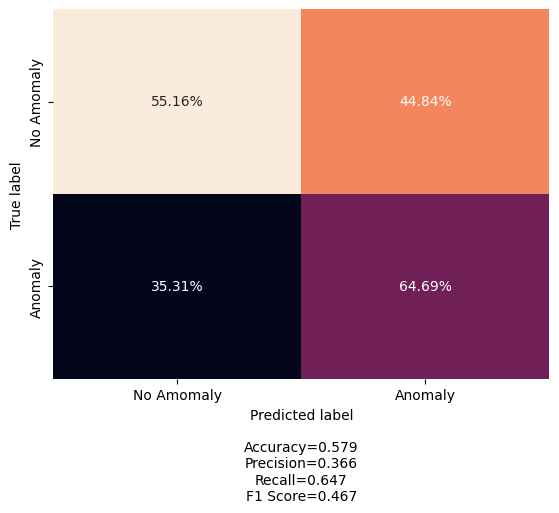

In [133]:
# y = dataframe_y_train.anomaly / dataframe_y_train.anomaly
# y.fillna(0, inplace=True)
# plot.make_confusion_matrix(
#     confusion_matrix(y, train_labels),
#     categories=["No Amomaly", "Anomaly",],
#     count=False,
#     cbar=False,
# )

y = dataframe_y_test.anomaly / dataframe_y_test.anomaly
y.fillna(0, inplace=True)
plot.make_confusion_matrix(
    confusion_matrix(y, test_labels),
    categories=["No Amomaly", "Anomaly",],
    count=False,
    cbar=False,
)

### One Class SVM

In [134]:
def train_evaluate_one_class_svm(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    nu: float = 0.01, # An upper bound on the fraction of training errors and a lower bound of the fraction of support vectors.
    kernel: str = 'rbf',
    gamma: str = 'scale'
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Trains and evaluates a One-Class SVM model for anomaly detection.
    """
    print(f"  Training One-Class SVM with nu={nu}, kernel={kernel}...")
    model = OneClassSVM(nu=nu, kernel=kernel, gamma=gamma)
    model.fit(X_train)

    # One-Class SVM provides a decision_function where higher is more normal
    # Convert to a score where higher is more anomalous for consistency
    train_scores = -model.decision_function(X_train)
    test_scores = -model.decision_function(X_test)

    # Predict labels (1 for normal, -1 for outlier by OCSVM, convert to 0/1)
    train_labels = (model.predict(X_train) == -1).astype(int)
    test_labels = (model.predict(X_test) == -1).astype(int)

    print(f"  One-Class SVM trained. Detected {np.sum(test_labels)} anomalies in test set.")
    return train_scores, train_labels, test_scores, test_labels

In [135]:
train_scores, train_labels, test_scores, test_labels = train_evaluate_one_class_svm(dataframe_X_train, dataframe_X_test)

  Training One-Class SVM with nu=0.01, kernel=rbf...
  One-Class SVM trained. Detected 430 anomalies in test set.


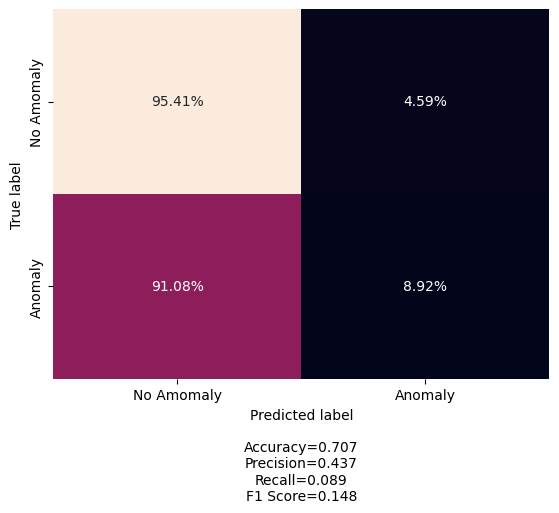

In [136]:
# y = dataframe_y_train.anomaly / dataframe_y_train.anomaly
# y.fillna(0, inplace=True)
# plot.make_confusion_matrix(
#     confusion_matrix(y, train_labels),
#     categories=["No Amomaly", "Anomaly",],
#     count=False,
#     cbar=False,
# )

y = dataframe_y_test.anomaly / dataframe_y_test.anomaly
y.fillna(0, inplace=True)
plot.make_confusion_matrix(
    confusion_matrix(y, test_labels),
    categories=["No Amomaly", "Anomaly",],
    count=False,
    cbar=False,
)